# 03 · TenSEAL encrypted inference
Encrypt a few FER2013 samples and run the Packed (im2col) TenSEAL demo pipeline.
This uses the FHE-friendly CNN architecture (Conv -> Square -> FC -> Square -> FC).


### 블록 1 · 의존성 임포트
TenSEAL 컨텍스트 생성기와 암호화 추론 헬퍼, 시각화용 Matplotlib을 불러옵니다.


In [18]:
import sys
from pathlib import Path

try:
    PROJECT_ROOT = Path(__file__).resolve().parents[1]
except NameError:
    PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))
print(f'Python path prepared with project root: {PROJECT_ROOT}')

# 코드 변경 후 커널 재시작 또는 모듈 리로드 필요
import importlib
import he.tenseal_context
import models.fhe_cnn
import he.fhe_inference

importlib.reload(he.tenseal_context)
importlib.reload(models.fhe_cnn)
importlib.reload(he.fhe_inference)
print("✅ 모듈 리로드 완료 (tenseal_context, models.fhe_cnn, he.fhe_inference)")

Python path prepared with project root: /Users/hyunwookkim/Documents/study/25y2s/보안프로젝트설계/프로젝트/프로토타입/learning_test_01/fhe_emotion
✅ 모듈 리로드 완료 (tenseal_context, models.fhe_cnn, he.fhe_inference)


In [19]:
from pathlib import Path

import matplotlib.pyplot as plt
import torch

from he.tenseal_context import create_context
from he.fhe_inference import encrypted_inference_demo


### 블록 2 · 테스트 데이터 로딩
전처리된 테스트 이미지를 메모리에 불러와 샘플 개수를 확인합니다.


In [20]:
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / 'data' / 'processed'
test_images = torch.load(DATA_DIR / 'test_images.pt')
test_labels = torch.load(DATA_DIR / 'test_labels.pt')
print('Loaded test tensors:', test_images.shape)


Loaded test tensors: torch.Size([3589, 1, 48, 48])


### 블록 3 · 암호화 추론 실행
CKKS 컨텍스트를 만들고 선택한 샘플들에 대해 이미지 출력과 `encrypted_inference_demo` 호출을 반복합니다.


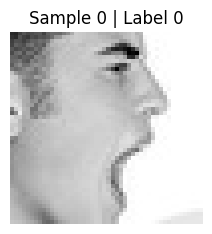

[INFO] Loading model weights from /Users/hyunwookkim/Documents/study/25y2s/보안프로젝트설계/프로젝트/프로토타입/learning_test_01/fhe_emotion/models/fhe_cnn_fer2013.pt
[INFO] Using packed TenSEAL runner for inference
[INFO] Using packed TenSEAL runner for inference
[INFO] Plain inference complete
[INFO] Plain inference complete
[INFO] Plain pred: 4 | Encrypted pred: 4
[INFO] Plain pred: 4 | Encrypted pred: 4


{'plain_logits': array([-0.13091129, -1.0774503 ,  0.13857627, -0.45785862,  0.35978982,
       -0.56502557,  0.05263241], dtype=float32), 'plain_probs': array([0.14490099, 0.05623345, 0.18971792, 0.10449126, 0.23669013,
       0.09387241, 0.17409383], dtype=float32), 'encrypted_logits': array([-0.08097613, -1.5113971 ,  0.22885044, -0.49070683,  0.4777622 ,
       -0.75619752, -0.03311513]), 'encrypted_probs': array([0.1521431 , 0.03639388, 0.20739975, 0.100997  , 0.2660169 ,
       0.07744749, 0.15960189]), 'plain_pred': 4, 'encrypted_pred': 4, 'true_label': 0}


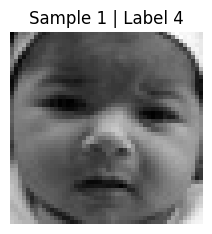

[INFO] Loading model weights from /Users/hyunwookkim/Documents/study/25y2s/보안프로젝트설계/프로젝트/프로토타입/learning_test_01/fhe_emotion/models/fhe_cnn_fer2013.pt
[INFO] Using packed TenSEAL runner for inference
[INFO] Using packed TenSEAL runner for inference
[INFO] Plain inference complete
[INFO] Plain inference complete
[INFO] Plain pred: 6 | Encrypted pred: 6
[INFO] Plain pred: 6 | Encrypted pred: 6


{'plain_logits': array([-0.38629192, -1.86968   , -0.40377003, -0.17381643, -0.2126568 ,
       -0.58761275,  0.07302814], dtype=float32), 'plain_probs': array([0.14211518, 0.03224135, 0.13965286, 0.17575894, 0.16906327,
       0.11620048, 0.22496794], dtype=float32), 'encrypted_logits': array([-0.37109479, -2.52632329, -0.44576727, -0.15361882, -0.24705411,
       -0.65851186,  0.03151528]), 'encrypted_probs': array([0.15004102, 0.01738626, 0.13924518, 0.18649132, 0.16985573,
       0.11256059, 0.22441989]), 'plain_pred': 6, 'encrypted_pred': 6, 'true_label': 4}


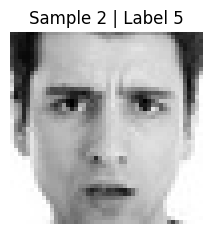

[INFO] Loading model weights from /Users/hyunwookkim/Documents/study/25y2s/보안프로젝트설계/프로젝트/프로토타입/learning_test_01/fhe_emotion/models/fhe_cnn_fer2013.pt
[INFO] Using packed TenSEAL runner for inference
[INFO] Using packed TenSEAL runner for inference
[INFO] Plain inference complete
[INFO] Plain inference complete
[INFO] Plain pred: 1 | Encrypted pred: 1
[INFO] Plain pred: 1 | Encrypted pred: 1


{'plain_logits': array([-1.0889761 ,  3.4452288 , -0.04564389, -5.9397817 , -0.9948207 ,
       -2.5885487 , -0.19354963], dtype=float32), 'plain_probs': array([9.9239573e-03, 9.2441094e-01, 2.8170746e-02, 7.7625911e-05,
       1.0903753e-02, 2.2152816e-03, 2.4297617e-02], dtype=float32), 'encrypted_logits': array([-1.20188207,  4.01169717,  0.12301269, -7.11145877, -1.15535893,
       -3.43749993, -0.36895918]), 'encrypted_probs': array([5.20915666e-03, 9.57185510e-01, 1.95957505e-02, 1.41341881e-05,
       5.45722878e-03, 5.56994517e-04, 1.19812252e-02]), 'plain_pred': 1, 'encrypted_pred': 1, 'true_label': 5}


[{'plain_logits': array([-0.13091129, -1.0774503 ,  0.13857627, -0.45785862,  0.35978982,
         -0.56502557,  0.05263241], dtype=float32),
  'plain_probs': array([0.14490099, 0.05623345, 0.18971792, 0.10449126, 0.23669013,
         0.09387241, 0.17409383], dtype=float32),
  'encrypted_logits': array([-0.08097613, -1.5113971 ,  0.22885044, -0.49070683,  0.4777622 ,
         -0.75619752, -0.03311513]),
  'encrypted_probs': array([0.1521431 , 0.03639388, 0.20739975, 0.100997  , 0.2660169 ,
         0.07744749, 0.15960189]),
  'plain_pred': 4,
  'encrypted_pred': 4,
  'true_label': 0},
 {'plain_logits': array([-0.38629192, -1.86968   , -0.40377003, -0.17381643, -0.2126568 ,
         -0.58761275,  0.07302814], dtype=float32),
  'plain_probs': array([0.14211518, 0.03224135, 0.13965286, 0.17575894, 0.16906327,
         0.11620048, 0.22496794], dtype=float32),
  'encrypted_logits': array([-0.37109479, -2.52632329, -0.44576727, -0.15361882, -0.24705411,
         -0.65851186,  0.03151528]),
 

In [21]:
# TenSEAL CKKS 컨텍스트를 한 번만 생성해 여러 샘플 추론에 재사용합니다.
context = create_context()
# 살펴볼 테스트 인덱스를 정의합니다.
sample_indices = [0, 1, 2]
records = []  # 평문/암호문 결과를 누적해 비교하기 위한 리스트
for idx in sample_indices:
    # 1) 원본 얼굴 이미지를 시각화하여 현재 추정 대상이 무엇인지 확인합니다.
    fig, ax = plt.subplots(figsize=(2.5, 2.5))
    ax.imshow(test_images[idx, 0], cmap='gray')
    ax.set_title(f'Sample {idx} | Label {int(test_labels[idx])}')
    ax.axis('off')
    plt.show()
    # 2) 동일한 컨텍스트로 암호화 추론을 실행합니다. (Packed TenSEAL 러너 사용)
    result = encrypted_inference_demo(context=context, sample_index=idx, use_packed=True)
    records.append(result)
    # 3) 로그 외에 노트북 셀에서도 바로 비교해볼 수 있도록 dict 전체를 출력합니다.
    print(result)
# 4) 마지막으로 모든 결과를 리스트 형태로 반환해 추가 분석에 활용할 수 있게 합니다.
records
